In [1]:
import seaborn as sns

tips = sns.load_dataset('tips')

In [2]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
q1 = tips['tip'].quantile(0.25) 
q3 = tips['tip'].quantile(0.75)
print(q1)
print(q3)

2.0
3.5625


In [4]:
iqr = q3 - q1
print(iqr)
lower = q1 - (1.5 * iqr)
upper = q3 + (1.5 * iqr)
print(lower)
print(upper)

1.5625
-0.34375
5.90625


In [5]:
outliers = tips[(tips['tip'] < lower) | (tips['tip'] > upper)]
print(outliers)
print(tips.shape)

     total_bill    tip     sex smoker   day    time  size
23        39.42   7.58    Male     No   Sat  Dinner     4
47        32.40   6.00    Male     No   Sun  Dinner     4
59        48.27   6.73    Male     No   Sat  Dinner     4
141       34.30   6.70    Male     No  Thur   Lunch     6
170       50.81  10.00    Male    Yes   Sat  Dinner     3
183       23.17   6.50    Male    Yes   Sun  Dinner     4
212       48.33   9.00    Male     No   Sat  Dinner     4
214       28.17   6.50  Female    Yes   Sat  Dinner     3
239       29.03   5.92    Male     No   Sat  Dinner     3
(244, 7)


In [6]:
tips_inline = tips[(tips['tip'] >= lower) & (tips['tip'] <= upper)]
tips_inline.shape

(235, 7)

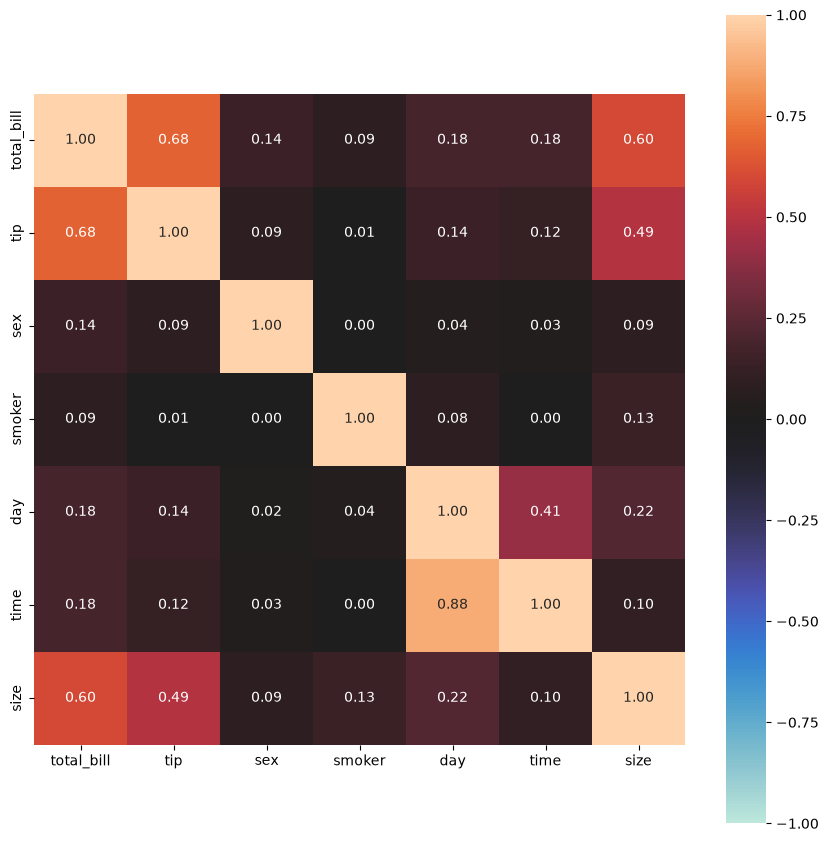

In [7]:
from dython.nominal import associations
import matplotlib.pyplot as plt
result = associations(tips, 
             nominal_columns='auto', 
             nom_nom_assoc='theil',
             num_num_assoc='pearson'
            )
plt.show()

In [8]:
from sklearn.ensemble import IsolationForest
import numpy as np

In [9]:
SEED = 42
X_outlier = tips.select_dtypes(np.number).copy()
iso = IsolationForest(contamination=0.10, n_estimators=100, random_state=SEED)
tips['outlier_iso'] = iso.fit_predict(X_outlier)
tips.head()

,total_bill,tip,sex,smoker,day,time,size,outlier_iso
0,16.99,1.01,Female,No,Sun,Dinner,2,1
1,10.34,1.66,Male,No,Sun,Dinner,3,1
2,21.01,3.50,Male,No,Sun,Dinner,3,1
3,23.68,3.31,Male,No,Sun,Dinner,2,1
4,24.59,3.61,Female,No,Sun,Dinner,4,1


In [10]:
print((tips['outlier_iso'] == -1).sum())

13


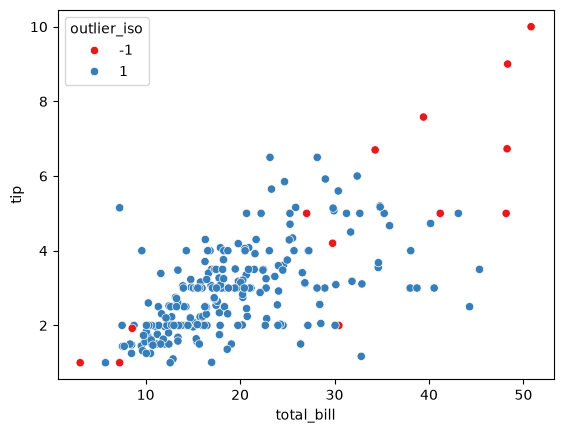

In [11]:
sns.scatterplot(tips, x=tips['total_bill'], y=tips['tip'], hue=tips['outlier_iso'], palette='Set1')
plt.show()

In [14]:
from sklearn.neighbors import LocalOutlierFactor

X_outlier = tips.select_dtypes(np.number).copy()
lof = LocalOutlierFactor(contamination=0.05, n_neighbors=20)
tips['outlier_lof'] = lof.fit_predict(X_outlier)
total_outlier_lof = (tips['outlier_lof'] == -1).sum()
print(total_outlier_lof)

13


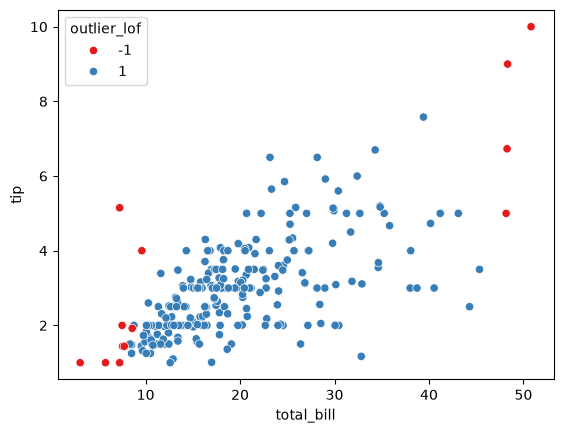

In [17]:
sns.scatterplot(tips, x=tips['total_bill'], y=tips['tip'],
               hue=tips['outlier_lof'], palette='Set1')
plt.show()

In [21]:
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

X_outlier = tips.select_dtypes(np.number).copy()
scaler = StandardScaler()
X_transform = scaler.fit_transform(X_outlier)
svm = OneClassSVM(nu=0.05, kernel='rbf', gamma='scale')
tips['outlier_svm'] = svm.fit_predict(X_transform)
tips.head()

,total_bill,tip,sex,smoker,day,time,size,outlier_iso,outlier_lof,outlier_svm
0,16.99,1.01,Female,No,Sun,Dinner,2,1,1,1
1,10.34,1.66,Male,No,Sun,Dinner,3,1,1,-1
2,21.01,3.50,Male,No,Sun,Dinner,3,1,1,1
3,23.68,3.31,Male,No,Sun,Dinner,2,1,1,1
4,24.59,3.61,Female,No,Sun,Dinner,4,1,1,1


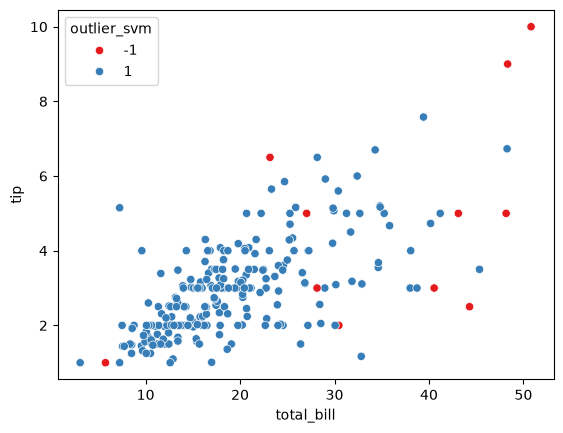

In [22]:
sns.scatterplot(tips, x=tips['total_bill'], y=tips['tip'],
               hue=tips['outlier_svm'], palette='Set1')
plt.show()

In [23]:
tips.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   total_bill   244 non-null    float64 
 1   tip          244 non-null    float64 
 2   sex          244 non-null    category
 3   smoker       244 non-null    category
 4   day          244 non-null    category
 5   time         244 non-null    category
 6   size         244 non-null    int64   
 7   outlier_iso  244 non-null    int64   
 8   outlier_lof  244 non-null    int64   
 9   outlier_svm  244 non-null    int64   
dtypes: category(4), float64(2), int64(4)
memory usage: 13.1 KB


In [24]:
tips['outlier_fin'] = tips['outlier_iso'] + tips['outlier_lof'] + tips['outlier_svm']
tips.head()

,total_bill,tip,sex,smoker,day,time,size,outlier_iso,outlier_lof,outlier_svm,outlier_fin
0,16.99,1.01,Female,No,Sun,Dinner,2,1,1,1,3
1,10.34,1.66,Male,No,Sun,Dinner,3,1,1,-1,1
2,21.01,3.50,Male,No,Sun,Dinner,3,1,1,1,3
3,23.68,3.31,Male,No,Sun,Dinner,2,1,1,1,3
4,24.59,3.61,Female,No,Sun,Dinner,4,1,1,1,3


In [29]:
outliers = tips[tips['outlier_fin'] < 0].copy()
print(outliers.shape)
outliers.head(10)

(10, 11)


,total_bill,tip,sex,smoker,day,time,size,outlier_iso,outlier_lof,outlier_svm,outlier_fin
59,48.27,6.73,Male,No,Sat,Dinner,4,-1,-1,1,-1
67,3.07,1.00,Female,Yes,Sat,Dinner,1,-1,-1,1,-1
92,5.75,1.00,Female,Yes,Fri,Dinner,2,1,-1,-1,-1
111,7.25,1.00,Female,No,Sat,Dinner,1,-1,-1,1,-1
143,27.05,5.00,Female,No,Thur,Lunch,6,-1,1,-1,-1
156,48.17,5.00,Male,No,Sun,Dinner,6,-1,-1,-1,-3
170,50.81,10.00,Male,Yes,Sat,Dinner,3,-1,-1,-1,-3
187,30.46,2.00,Male,Yes,Sun,Dinner,5,-1,1,-1,-1
212,48.33,9.00,Male,No,Sat,Dinner,4,-1,-1,-1,-3
222,8.58,1.92,Male,Yes,Fri,Lunch,1,-1,-1,1,-1


In [30]:
tips_limpo = tips[tips['outlier_fin'] > 0].copy()
tips_limpo.shape

(234, 11)

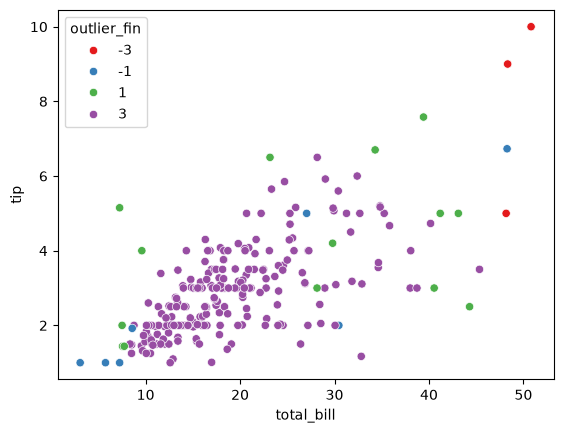

In [31]:
sns.scatterplot(tips, x=tips['total_bill'], y=tips['tip'],
               hue=tips['outlier_fin'], palette='Set1')
plt.show()